In [3]:
# fusion using YOLO racket detecion rather than HSV ball detection





!pip install mediapipe==0.10.32 opencv-python-headless ultralytics librosa scikit-learn scipy -q

import os, cv2, pickle, warnings
import numpy as np
import pandas as pd
import mediapipe as mp
import tensorflow as tf
import librosa
from scipy.signal import find_peaks, resample
from scipy.stats import skew, kurtosis
from ultralytics import YOLO
from google.colab import files
warnings.filterwarnings('ignore')

SELECTED_JOINTS       = [11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27]
WINDOW_SIZE           = 30
THRESHOLD             = 0.70
STRIDE                = 1
COOLDOWN_FRAMES       = 180
RACKET_MOVE_THRESHOLD = 20
MERGE_WINDOW_SEC      = 0.75

LABELS    = ['Forehand', 'Backhand', 'Serve']
LABEL_MAP = {0: 'Forehand', 1: 'Backhand', 2: 'Serve'}
GT_MAP    = {'F': 0, 'B': 1, 'S': 2}


V1_GT = [GT_MAP[x] for x in ['S','B','F','F','B','F','S','F','S','F']]

print(" Imports ready")
print(f"   GT loaded: {len(V1_GT)} strokes — {['S','B','F','F','B','F','S','F','S','F']}")

 Imports ready
   GT loaded: 10 strokes — ['S', 'B', 'F', 'F', 'B', 'F', 'S', 'F', 'S', 'F']


In [4]:

print("\n1. Upload tennis_cnn_lstm_v1.h5")
u1 = files.upload()
camera_model = tf.keras.models.load_model(list(u1.keys())[0])
print(f" Camera CNN-LSTM — input: {camera_model.input_shape}")

print("\n2. Upload Au8dio_svm.pkl")
u2 = files.upload()
with open(list(u2.keys())[0], 'rb') as f:
    audio_data = pickle.load(f)
svm_audio    = audio_data['svm']
scaler_audio = audio_data['scaler']
N_MFCC_AUDIO = audio_data['n_mfcc']
CLIP_AUDIO   = audio_data['clip_duration']
print(f" Audio SVM — n_mfcc={N_MFCC_AUDIO}, clip={CLIP_AUDIO}s")

print("\n3. Upload accel_cnn_lstm_v4.h5")
u3 = files.upload()
accel_cnn = tf.keras.models.load_model(list(u3.keys())[0])
print(f" Accel CNN-LSTM — input: {accel_cnn.input_shape}")

print("\n4. Upload accel_svm_v4.pkl")
u4 = files.upload()
with open(list(u4.keys())[0], 'rb') as f:
    svm_data = pickle.load(f)
svm_model  = svm_data['model']
svm_scaler = svm_data['scaler']
print(" Accel SVM loaded")

print("\n5. Loading YOLOv8")
yolo = YOLO('yolov8n.pt')
print(" YOLO loaded")


1. Upload tennis_cnn_lstm_v1.h5


Saving tennis_cnn_lstm_v1.h5 to tennis_cnn_lstm_v1.h5


 Camera CNN-LSTM — input: (None, 30, 22)

2. Upload Au8dio_svm.pkl


Saving Au8dio_svm.pkl to Au8dio_svm.pkl
 Audio SVM — n_mfcc=40, clip=0.5s

3. Upload accel_cnn_lstm_v4.h5


Saving accel_cnn_lstm_v4.h5 to accel_cnn_lstm_v4.h5
 Accel CNN-LSTM — input: (None, 60, 4)

4. Upload accel_svm_v4.pkl


Saving accel_svm_v4.pkl to accel_svm_v4.pkl
 Accel SVM loaded

5. Loading YOLOv8
 YOLO loaded


In [5]:

print("\n6. Upload session1.mp4")
uv1 = files.upload()
V1_VIDEO = list(uv1.keys())[0]
print(f" {V1_VIDEO}")

print("\n7. Upload results_1.csv (accel data for V1)")
ua1 = files.upload()
V1_ACCEL = list(ua1.keys())[0]
print(f" {V1_ACCEL}")

print("\n All files uploaded")


6. Upload session1.mp4


Saving ss1.mp4 to ss1.mp4
 ss1.mp4

7. Upload results_1.csv (accel data for V1)


Saving results 1.csv to results 1.csv
 results 1.csv

 All files uploaded


In [6]:

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import urllib.request
from scipy.signal import find_peaks, resample
from scipy.stats import skew, kurtosis
import pandas as pd

MODEL_PATH = "pose_landmarker.task"
if not os.path.exists(MODEL_PATH):
    print("Downloading pose model")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
        "pose_landmarker_lite/float16/latest/pose_landmarker_lite.task",
        MODEL_PATH
    )
    print(" Downloaded")

def make_pose_detector():
    opts = mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=mp_vision.RunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=0.4,
        min_pose_presence_confidence=0.4,
        min_tracking_confidence=0.5
    )
    return mp_vision.PoseLandmarker.create_from_options(opts)

def extract_skeleton(pose_detector, frame):
    h, w = frame.shape[:2]
    rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = pose_detector.detect(mp_img)
    if not result.pose_landmarks or len(result.pose_landmarks) == 0:
        return None
    lm  = result.pose_landmarks[0]
    pts = [[lm[i].x, lm[i].y] for i in SELECTED_JOINTS]
    return pts

def hip_normalise_and_predict(buffer):

    seq   = np.array(buffer)
    hip_x = (seq[:, 12] + seq[:, 14]) / 2.0
    hip_y = (seq[:, 13] + seq[:, 15]) / 2.0
    seq_3d = seq.reshape(WINDOW_SIZE, 11, 2)
    hip_3d = np.stack([hip_x, hip_y], axis=1)[:, None, :]
    seq_3d = seq_3d - hip_3d
    seq_inp = seq_3d.reshape(1, WINDOW_SIZE, 22)
    probs  = camera_model.predict(seq_inp, verbose=0)[0]
    cls    = int(np.argmax(probs))
    conf   = float(probs[cls])
    return cls, conf

def get_racket_center(frame):
    results = yolo(frame, classes=[38], verbose=False)[0]
    best_conf   = 0
    best_center = None
    for box in results.boxes:
        conf = float(box.conf)
        if conf > 0.25 and conf > best_conf:
            x1,y1,x2,y2 = map(int, box.xyxy[0])
            best_center  = ((x1+x2)//2, (y1+y2)//2)
            best_conf    = conf
    return best_center, best_conf


CLIP_SEC = 0.6
N_ACCEL  = 60

def load_accel(path):
    df = pd.read_csv(path, comment='#')
    df.columns = ['time', 'ax', 'ay', 'az', 'aT']
    return df

def get_accel_clip(df, t_center):
    t0, t1 = t_center - CLIP_SEC/2, t_center + CLIP_SEC/2
    c = df[(df.time >= t0) & (df.time < t1)]
    return c if len(c) >= 20 else None

def handcrafted_features(clip):
    feats = []
    for col in ['ax', 'ay', 'az', 'aT']:
        sig = clip[col].values
        pv  = np.max(np.abs(sig)) + 1e-8
        sn  = sig / pv
        feats += [np.mean(sn), np.std(sn), np.max(sn), np.min(sn),
                  np.max(sn)-np.min(sn), float(skew(sn)),
                  float(kurtosis(sn)), pv, np.sqrt(np.mean(sig**2))]
    aT = clip['aT'].values
    ax = clip['ax'].values
    feats.append(np.max(aT))
    feats.append(float(np.sum(np.diff(np.sign(ax))!=0))/len(ax))
    feats.append(np.sum(aT**2)/len(aT))
    total = sum(np.mean(np.abs(clip[c].values))
                for c in ['ax','ay','az']) + 1e-8
    for col in ['ax', 'ay', 'az']:
        feats.append(np.mean(np.abs(clip[col].values))/total)
    return np.array(feats, dtype=np.float32)

def raw_window_accel(df, t_center):
    clip = get_accel_clip(df, t_center)
    if clip is None: return None
    raw  = clip[['ax','ay','az','aT']].values
    norm = raw / (np.max(np.abs(raw), axis=0) + 1e-8)
    return resample(norm, N_ACCEL, axis=0).astype(np.float32)

def detect_accel_standalone(csv_path, label=""):

    df = load_accel(csv_path)

    peak_times = []
    for col in ['ax', 'ay', 'az']:
        sig   = df[col].values
        sig_n = np.abs(sig) / (np.max(np.abs(sig)) + 1e-8)
        peaks, _ = find_peaks(sig_n, height=0.4,
                              distance=50, prominence=0.2)
        for p in peaks:
            peak_times.append(df['time'].iloc[p])

    if not peak_times:
        print(f"    {label}: no peaks found"); return []

    peak_times = sorted(peak_times)
    stroke_times = []
    cluster = [peak_times[0]]
    for t in peak_times[1:]:
        if t - cluster[-1] <= 0.3:
            cluster.append(t)
        else:
            stroke_times.append(np.mean(cluster))
            cluster = [t]
    stroke_times.append(np.mean(cluster))

    filtered = [stroke_times[0]]
    for t in stroke_times[1:]:
        if t - filtered[-1] >= 1.0:
            filtered.append(t)
    stroke_times = filtered

    print(f"  Accel {label}: {len(stroke_times)} stroke events")

    detections = []
    for t_csv in stroke_times:
        clip = get_accel_clip(df, t_csv)
        rw   = raw_window_accel(df, t_csv)
        if clip is None or rw is None: continue

        feat     = handcrafted_features(clip)
        X_sc     = svm_scaler.transform([feat])
        svm_pred = int(svm_model.predict(X_sc)[0])
        svm_prob = float(svm_model.predict_proba(X_sc)[0][svm_pred])

        cnn_prob = accel_cnn.predict(rw[np.newaxis], verbose=0)[0]
        cnn_pred = int(np.argmax(cnn_prob))
        cnn_conf = float(cnn_prob[cnn_pred])

        print(f"    t_csv={t_csv:.2f}s  "
              f"SVM:{LABELS[svm_pred]:<10}({svm_prob:.2f})  "
              f"CNN:{LABELS[cnn_pred]:<10}({cnn_conf:.2f})")

        detections.append((t_csv, svm_pred, svm_prob*100,
                           cnn_pred, cnn_conf*100))

    return detections

print(" Helper functions define")

 Helper functions define


In [8]:

print("Running accel detection")


df_v1      = load_accel(V1_ACCEL)
acc_det_v1 = detect_accel_standalone(V1_ACCEL, "V1")[1:]

print(f"\n  Accel detected: {len(acc_det_v1)} strokes")
for i, (t_csv, sp, sc, cp, cc) in enumerate(acc_det_v1):
    print(f"  {i+1}  t_csv={t_csv:.2f}s  "
          f"SVM:{LABELS[sp]:<10}({sc:.1f}%)  "
          f"CNN:{LABELS[cp]:<10}({cc:.1f}%)")

Running accel detection
  Accel V1: 11 stroke events
    t_csv=7.21s  SVM:Serve     (0.96)  CNN:Serve     (1.00)
    t_csv=22.76s  SVM:Serve     (0.99)  CNN:Serve     (1.00)
    t_csv=26.05s  SVM:Backhand  (0.98)  CNN:Backhand  (1.00)
    t_csv=29.47s  SVM:Forehand  (0.96)  CNN:Forehand  (1.00)
    t_csv=39.51s  SVM:Forehand  (0.97)  CNN:Forehand  (1.00)
    t_csv=42.65s  SVM:Backhand  (0.98)  CNN:Backhand  (1.00)
    t_csv=45.59s  SVM:Forehand  (0.99)  CNN:Forehand  (1.00)
    t_csv=55.00s  SVM:Serve     (0.96)  CNN:Serve     (1.00)
    t_csv=57.37s  SVM:Forehand  (0.58)  CNN:Serve     (0.86)
    t_csv=66.74s  SVM:Serve     (0.97)  CNN:Serve     (1.00)
    t_csv=69.23s  SVM:Forehand  (0.97)  CNN:Forehand  (1.00)

  Accel detected: 10 strokes
  1  t_csv=22.76s  SVM:Serve     (99.0%)  CNN:Serve     (100.0%)
  2  t_csv=26.05s  SVM:Backhand  (97.7%)  CNN:Backhand  (100.0%)
  3  t_csv=29.47s  SVM:Forehand  (96.0%)  CNN:Forehand  (100.0%)
  4  t_csv=39.51s  SVM:Forehand  (97.0%)  CNN:Foreha

In [9]:

# Audio Detection

def extract_audio_features(clip, sr):
    if len(clip) < sr * 0.1: return None
    try:
        mfcc   = librosa.feature.mfcc(y=clip, sr=sr, n_mfcc=N_MFCC_AUDIO)
        chroma = librosa.feature.chroma_stft(y=clip, sr=sr)
        zcr    = librosa.feature.zero_crossing_rate(clip)
        rmse   = librosa.feature.rms(y=clip)
        return np.concatenate([
            mfcc.mean(axis=1), mfcc.std(axis=1),
            chroma.mean(axis=1),
            zcr.mean(axis=1), rmse.mean(axis=1)
        ])
    except:
        return None

def detect_audio(video_path):

    audio_tmp = '/tmp/aud_v1.wav'
    os.system(f'ffmpeg -y -i "{video_path}" -q:a 0 -map a "{audio_tmp}" -loglevel quiet')
    if not os.path.exists(audio_tmp):
        print("    Audio extraction failed"); return []

    y, sr      = librosa.load(audio_tmp, sr=None)
    duration   = len(y) / sr
    detections = []
    last_t     = -1.0
    PROB_THRESH = 0.60
    MIN_GAP     = 1.5
    STEP        = 0.1

    t = CLIP_AUDIO / 2
    while t < duration - CLIP_AUDIO / 2:
        start = max(0, t - 0.1)
        end   = min(duration, t + CLIP_AUDIO)
        clip  = y[int(start*sr):int(end*sr)]
        feat  = extract_audio_features(clip, sr)
        if feat is not None:
            prob = svm_audio.predict_proba(
                scaler_audio.transform([feat]))[0][1]
            if prob >= PROB_THRESH and (t - last_t) >= MIN_GAP:
                detections.append((t, prob))
                last_t = t
        t += STEP

    print(f" Audio: {len(detections)} contacts")
    print(f"   Times: {[round(d[0],2) for d in detections]}")
    return detections

print("\n Running audio detection")
aud_det_v1 = detect_audio(V1_VIDEO)


 Running audio detection
 Audio: 9 contacts
   Times: [1.15, 4.35, 7.95, 13.55, 15.15, 16.85, 28.65, 30.65, 32.65]


In [10]:

print("\n Running camera detection with YOLO racket trigger")

pose_det = make_pose_detector()

cap    = cv2.VideoCapture(V1_VIDEO)
fps    = cap.get(cv2.CAP_PROP_FPS) or 60.0
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

output_name = V1_VIDEO.replace('.mp4','') + '_fusion_yolo.mp4'
out = cv2.VideoWriter(output_name,
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      fps, (width, height))

print(f"  {fps:.0f}fps  {width}x{height}  {total} frames")


skeleton_buffer   = []
prev_skel         = None
cam_detections    = []
last_det_frame    = -COOLDOWN_FRAMES
last_label        = None
last_label_frame  = -999


prev_racket_center = None
racket_velocity    = 0.0
racket_det_count   = 0

frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    canvas = frame.copy()


    pts = extract_skeleton(pose_det, frame)
    if pts is None:
        pts = prev_skel if prev_skel is not None \
              else [[0.0,0.0]] * len(SELECTED_JOINTS)
    prev_skel = pts

    skeleton_buffer.append(np.array(pts).flatten())
    if len(skeleton_buffer) > WINDOW_SIZE:
        skeleton_buffer.pop(0)


    racket_center, racket_conf = get_racket_center(frame)

    if racket_center is not None:
        racket_det_count += 1
        if prev_racket_center is not None:
            dx = racket_center[0] - prev_racket_center[0]
            dy = racket_center[1] - prev_racket_center[1]
            racket_velocity = np.sqrt(dx**2 + dy**2)
        else:
            racket_velocity = 0.0
        prev_racket_center = racket_center
    else:
        racket_velocity    = 0.0
        prev_racket_center = None


    racket_swinging = (racket_velocity >= RACKET_MOVE_THRESHOLD
                       and racket_center is not None)

    if (racket_swinging
            and len(skeleton_buffer) == WINDOW_SIZE
            and (frame_idx - last_det_frame) >= COOLDOWN_FRAMES):

        cls, conf = hip_normalise_and_predict(skeleton_buffer)

        if conf >= THRESHOLD:
            t_sec = frame_idx / fps
            cam_detections.append((t_sec, cls, conf))
            last_det_frame   = frame_idx
            last_label       = (cls, conf)
            last_label_frame = frame_idx
            print(f"  frame={frame_idx:5d}  t={t_sec:.2f}s  "
                  f"{LABEL_MAP[cls]:<10}  conf={conf:.3f}  "
                  f"racket_v={racket_velocity:.1f}px")




    for j in range(len(pts)):
        x = int(pts[j][0] * width)
        y = int(pts[j][1] * height)
        cv2.circle(canvas, (x,y), 5, (255,255,255), -1)


    if racket_center:
        col = (0,80,255) if racket_swinging else (0,200,255)
        cv2.circle(canvas, racket_center, 14, col, 3)
        cv2.putText(canvas,
                    f"RACKET v={racket_velocity:.0f}px",
                    (racket_center[0]+16, racket_center[1]),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2)
        if racket_swinging:
            cv2.putText(canvas, "SWING!",
                        (racket_center[0]-20, racket_center[1]-20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)


    show = (last_label is not None and
            last_label_frame <= frame_idx <
            last_label_frame + WINDOW_SIZE)
    if show:
        cls, conf = last_label
        label = LABEL_MAP[cls]
        colors = {0:(0,200,80), 1:(0,80,200), 2:(200,0,80)}
        col = colors[cls]
        cv2.putText(canvas, label.upper(), (80,140),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.8, (0,0,0), 10)
        cv2.putText(canvas, label.upper(), (80,140),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.8, col, 6)
        cv2.putText(canvas, f"conf={conf:.2f}", (80,190),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, col, 2)


    f_c = sum(1 for d in cam_detections if d[1]==0)
    b_c = sum(1 for d in cam_detections if d[1]==1)
    s_c = sum(1 for d in cam_detections if d[1]==2)
    cv2.putText(canvas, f"F:{f_c} B:{b_c} S:{s_c}",
                (width-220, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 4)
    cv2.putText(canvas, f"F:{f_c} B:{b_c} S:{s_c}",
                (width-220, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2)


    bar_w = min(int(racket_velocity * 2), width//3)
    bar_col = (0,0,255) if racket_swinging else (0,200,100)
    cv2.rectangle(canvas, (10, height-30), (10+bar_w, height-10), bar_col, -1)
    cv2.putText(canvas, f"Racket v={racket_velocity:.0f}",
                (10, height-35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 1)
    cv2.putText(canvas, f"t={frame_idx/fps:.2f}s",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

    out.write(canvas)
    frame_idx += 1

    if frame_idx % 300 == 0:
        print(f"  Progress: {frame_idx}/{total} ({frame_idx/total*100:.0f}%)  "
              f"Racket detected: {racket_det_count}  "
              f"Strokes: {len(cam_detections)}")

cap.release()
out.release()
pose_det.close()

print(f"\n Done — {frame_idx} frames")
print(f"   Racket detected in {racket_det_count} frames ({racket_det_count/frame_idx*100:.1f}%)")
print(f"   Camera strokes: {len(cam_detections)}")


 Running camera detection with YOLO racket trigger
  60fps  2340x1080  2019 frames
  frame=   29  t=0.48s  Forehand    conf=1.000  racket_v=31.8px
  frame=  227  t=3.79s  Forehand    conf=1.000  racket_v=23.2px
  Progress: 300/2019 (15%)  Racket detected: 163  Strokes: 2
  frame=  480  t=8.02s  Forehand    conf=1.000  racket_v=26.2px
  Progress: 600/2019 (30%)  Racket detected: 212  Strokes: 3
  frame=  698  t=11.66s  Forehand    conf=1.000  racket_v=24.7px
  Progress: 900/2019 (45%)  Racket detected: 290  Strokes: 4
  frame=  929  t=15.52s  Backhand    conf=1.000  racket_v=22.2px
  frame= 1112  t=18.58s  Forehand    conf=1.000  racket_v=20.2px
  Progress: 1200/2019 (59%)  Racket detected: 373  Strokes: 6
  frame= 1296  t=21.65s  Forehand    conf=1.000  racket_v=357.3px
  frame= 1478  t=24.69s  Forehand    conf=1.000  racket_v=25.3px
  Progress: 1500/2019 (74%)  Racket detected: 516  Strokes: 8
  frame= 1676  t=28.00s  Serve       conf=0.976  racket_v=28.0px
  Progress: 1800/2019 (89%

In [11]:

print("\n Merging camera + audio + accel")

merged = []
for t_cam, cam_cls, cam_conf in cam_detections:


    aud_ok, aud_conf = False, 0.0
    for t_aud, a_conf in aud_det_v1:
        if abs(t_aud - t_cam) <= MERGE_WINDOW_SEC:
            aud_ok, aud_conf = True, a_conf
            break


    svm_pred, svm_conf = -1, 0.0
    cnn_pred, cnn_conf = -1, 0.0
    for t_csv, sp, sc, cp, cc in acc_det_v1:
        if abs(t_csv - t_cam) <= MERGE_WINDOW_SEC:
            svm_pred, svm_conf = sp, sc
            cnn_pred, cnn_conf = cp, cc
            break


    votes = np.zeros(3)
    votes[cam_cls] += 2.0 * cam_conf
    if cnn_pred >= 0: votes[cnn_pred] += 2.0 * (cnn_conf/100)
    if svm_pred >= 0: votes[svm_pred] += 1.0 * (svm_conf/100)
    total = np.sum(votes)
    if total == 0:
        fusion_cls, fusion_conf = cam_cls, cam_conf
    else:
        votes      /= total
        fusion_cls  = int(np.argmax(votes))
        fusion_conf = float(np.max(votes))

    tag = "Cam"
    if aud_ok:   tag += "+Aud"
    if svm_pred >= 0: tag += "+Accel"

    merged.append({
        't'          : t_cam,
        'cam'        : cam_cls,
        'cam_conf'   : cam_conf,
        'svm'        : svm_pred,
        'svm_conf'   : svm_conf,
        'cnn'        : cnn_pred,
        'cnn_conf'   : cnn_conf,
        'fusion'     : fusion_cls,
        'fusion_conf': fusion_conf,
        'audio'      : aud_ok,
        'audio_conf' : aud_conf,
        'tag'        : tag,
    })

    print(f"  t={t_cam:.2f}s  "
          f"Cam:{LABELS[cam_cls]:<10}  "
          f"SVM:{LABELS[svm_pred][:8] if svm_pred>=0 else 'N/A':>8}  "
          f"CNN:{LABELS[cnn_pred][:8] if cnn_pred>=0 else 'N/A':>8}  "
          f"→ FUSION:{LABELS[fusion_cls]:<10}  [{tag}]")

print(f"\n  Merged: {len(merged)} strokes")
print(f"  Audio confirmed : {sum(1 for m in merged if m['audio'])}")
print(f"  Accel confirmed : {sum(1 for m in merged if m['svm']>=0)}")


 Merging camera + audio + accel
  t=0.48s  Cam:Forehand    SVM:     N/A  CNN:     N/A  → FUSION:Forehand    [Cam+Aud]
  t=3.79s  Cam:Forehand    SVM:     N/A  CNN:     N/A  → FUSION:Forehand    [Cam+Aud]
  t=8.02s  Cam:Forehand    SVM:     N/A  CNN:     N/A  → FUSION:Forehand    [Cam+Aud]
  t=11.66s  Cam:Forehand    SVM:     N/A  CNN:     N/A  → FUSION:Forehand    [Cam]
  t=15.52s  Cam:Backhand    SVM:     N/A  CNN:     N/A  → FUSION:Backhand    [Cam+Aud]
  t=18.58s  Cam:Forehand    SVM:     N/A  CNN:     N/A  → FUSION:Forehand    [Cam]
  t=21.65s  Cam:Forehand    SVM:     N/A  CNN:     N/A  → FUSION:Forehand    [Cam]
  t=24.69s  Cam:Forehand    SVM:     N/A  CNN:     N/A  → FUSION:Forehand    [Cam]
  t=28.00s  Cam:Serve       SVM:     N/A  CNN:     N/A  → FUSION:Serve       [Cam+Aud]
  t=31.01s  Cam:Forehand    SVM:     N/A  CNN:     N/A  → FUSION:Forehand    [Cam+Aud]

  Merged: 10 strokes
  Audio confirmed : 6
  Accel confirmed : 0


In [12]:



print(f"Ground truth    : {len(V1_GT)} strokes")
print(f"Camera detected : {len(cam_detections)} strokes")
print(f"Accel detected  : {len(acc_det_v1)} strokes")
print(f"Audio detected  : {len(aud_det_v1)} contacts")


print("\n" + "═"*55)
print("CAMERA ALONE (YOLO trigger + CNN-LSTM)")
print("═"*55)
n = min(len(cam_detections), len(V1_GT))
cc = 0
for i in range(n):
    t, cls, conf = cam_detections[i]
    gt = V1_GT[i]
    mk = '✅' if cls == gt else '❌'
    print(f"  {i+1:<2}  t={t:.2f}s  GT:{LABELS[gt]:<10}  "
          f"Pred:{LABELS[cls]:<10}  {mk}  conf={conf:.2f}")
    if cls == gt: cc += 1
for i in range(n, len(V1_GT)):
    print(f"  {i+1:<2}  MISSED  GT:{LABELS[V1_GT[i]]}")
print(f"\n  Camera: {cc}/{len(V1_GT)} = {cc/len(V1_GT)*100:.1f}%")


print("\n" + "═"*55)
print("ACCEL ALONE (SVM + CNN-LSTM, independent peaks)")
print("═"*55)
n = min(len(acc_det_v1), len(V1_GT))
cs = cn = 0
for i in range(n):
    t_csv, sp, sc, cp, cc_val = acc_det_v1[i]
    gt = V1_GT[i]
    mks = '✅' if sp == gt else '❌'
    mkc = '✅' if cp == gt else '❌'
    print(f"  {i+1:<2}  t_csv={t_csv:.2f}s  GT:{LABELS[gt]:<10}  "
          f"SVM:{LABELS[sp]:<10}{mks}({sc:.0f}%)  "
          f"CNN:{LABELS[cp]:<10}{mkc}({cc_val:.0f}%)")
    if sp == gt: cs += 1
    if cp == gt: cn += 1
for i in range(n, len(V1_GT)):
    print(f"  {i+1:<2}  MISSED  GT:{LABELS[V1_GT[i]]}")
print(f"\n  Accel SVM : {cs}/{len(V1_GT)} = {cs/len(V1_GT)*100:.1f}%")
print(f"  Accel CNN : {cn}/{len(V1_GT)} = {cn/len(V1_GT)*100:.1f}%")


print("\n" + "═"*55)
print("AUDIO — contact detection only (no classification)")
print("═"*55)
print(f"  Audio found {len(aud_det_v1)} contacts out of {len(V1_GT)} strokes")
print(f"  Times: {[round(d[0],2) for d in aud_det_v1]}")
audio_recall = len(aud_det_v1) / len(V1_GT) * 100
print(f"  Recall: {len(aud_det_v1)}/{len(V1_GT)} = {audio_recall:.1f}%")


print("\n" + "═"*55)
print("FUSION — Camera + Accel (matched by order)")
print("═"*55)
n = min(len(cam_detections), len(acc_det_v1), len(V1_GT))
cf = 0
for i in range(n):
    t_cam, cam_cls, cam_conf       = cam_detections[i]
    t_csv, sp, sc, cp, cc_val      = acc_det_v1[i]
    gt = V1_GT[i]


    votes = np.zeros(3)
    votes[cam_cls] += 2.0 * cam_conf
    votes[cp]      += 2.0 * (cc_val/100)
    votes[sp]      += 1.0 * (sc/100)
    votes /= np.sum(votes)
    fusion_cls  = int(np.argmax(votes))
    fusion_conf = float(np.max(votes))

    # Audio confirmed?
    aud_ok = any(abs(t_a - t_cam) <= MERGE_WINDOW_SEC
                 for t_a, _ in aud_det_v1)

    mk = '✅' if fusion_cls == gt else '❌'
    aud = '🎵' if aud_ok else '  '
    print(f"  {i+1:<2}  GT:{LABELS[gt]:<10}  "
          f"Cam:{LABELS[cam_cls]:<10}  "
          f"CNN:{LABELS[cp]:<10}  "
          f"SVM:{LABELS[sp]:<10}  "
          f"→ FUSION:{LABELS[fusion_cls]:<10}{mk}  {aud}")
    if fusion_cls == gt: cf += 1

for i in range(n, len(V1_GT)):
    print(f"  {i+1:<2}  MISSED  GT:{LABELS[V1_GT[i]]}")

print(f"\n  Camera alone : {cc}/{len(V1_GT)} = {cc/len(V1_GT)*100:.1f}%")
print(f"  Accel SVM    : {cs}/{len(V1_GT)} = {cs/len(V1_GT)*100:.1f}%")
print(f"  Accel CNN    : {cn}/{len(V1_GT)} = {cn/len(V1_GT)*100:.1f}%")
print(f"  FUSION       : {cf}/{len(V1_GT)} = {cf/len(V1_GT)*100:.1f}%  ← REPORT THIS")
print(f"  Audio recall : {len(aud_det_v1)}/{len(V1_GT)} = {audio_recall:.1f}%")
print("═"*55)

Ground truth    : 10 strokes
Camera detected : 10 strokes
Accel detected  : 10 strokes
Audio detected  : 9 contacts

═══════════════════════════════════════════════════════
CAMERA ALONE (YOLO trigger + CNN-LSTM)
═══════════════════════════════════════════════════════
  1   t=0.48s  GT:Serve       Pred:Forehand    ❌  conf=1.00
  2   t=3.79s  GT:Backhand    Pred:Forehand    ❌  conf=1.00
  3   t=8.02s  GT:Forehand    Pred:Forehand    ✅  conf=1.00
  4   t=11.66s  GT:Forehand    Pred:Forehand    ✅  conf=1.00
  5   t=15.52s  GT:Backhand    Pred:Backhand    ✅  conf=1.00
  6   t=18.58s  GT:Forehand    Pred:Forehand    ✅  conf=1.00
  7   t=21.65s  GT:Serve       Pred:Forehand    ❌  conf=1.00
  8   t=24.69s  GT:Forehand    Pred:Forehand    ✅  conf=1.00
  9   t=28.00s  GT:Serve       Pred:Serve       ✅  conf=0.98
  10  t=31.01s  GT:Forehand    Pred:Forehand    ✅  conf=1.00

  Camera: 7/10 = 70.0%

═══════════════════════════════════════════════════════
ACCEL ALONE (SVM + CNN-LSTM, independent pea

In [13]:

files.download(output_name)
print(f"  {output_name}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ss1_fusion_yolo.mp4


═══════════════════════════════════════════════════════
METRICS — weighted average
═══════════════════════════════════════════════════════
  Camera CNN-LSTM       P=0.81  R=0.70  F1=0.67
  Accel SVM             P=1.00  R=1.00  F1=1.00
  Accel CNN-LSTM        P=0.93  R=0.90  F1=0.90
  FUSION                P=1.00  R=1.00  F1=1.00

Confusion Matrix — FUSION


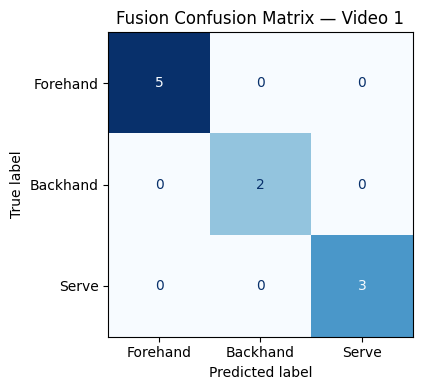

 Saved fusion_confusion_v1.png


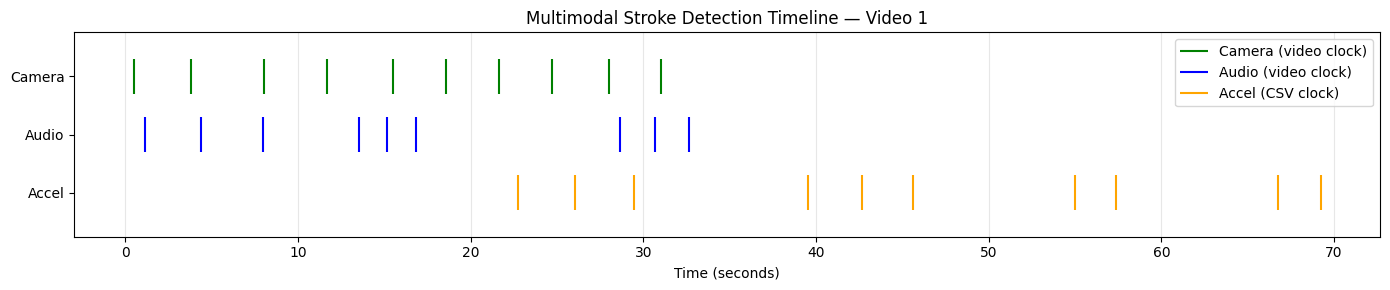

 Saved fusion_timeline_v1.png


In [14]:

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

n = min(len(cam_detections), len(acc_det_v1), len(V1_GT))

y_true       = V1_GT[:n]
y_cam        = [cam_detections[i][1] for i in range(n)]
y_svm        = [acc_det_v1[i][1]     for i in range(n)]
y_cnn        = [acc_det_v1[i][3]     for i in range(n)]


y_fusion = []
for i in range(n):
    t_cam, cam_cls, cam_conf  = cam_detections[i]
    t_csv, sp, sc, cp, cc_val = acc_det_v1[i]
    votes = np.zeros(3)
    votes[cam_cls] += 2.0 * cam_conf
    votes[cp]      += 2.0 * (cc_val/100)
    votes[sp]      += 1.0 * (sc/100)
    votes /= np.sum(votes)
    y_fusion.append(int(np.argmax(votes)))

print("═"*55)
print("METRICS — weighted average")
print("═"*55)
for name, y_pred in [("Camera CNN-LSTM", y_cam),
                      ("Accel SVM",       y_svm),
                      ("Accel CNN-LSTM",  y_cnn),
                      ("FUSION",          y_fusion)]:
    p = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    r = recall_score   (y_true, y_pred, average='weighted', zero_division=0)
    f = f1_score       (y_true, y_pred, average='weighted', zero_division=0)
    print(f"  {name:<20}  P={p:.2f}  R={r:.2f}  F1={f:.2f}")


print("\nConfusion Matrix — FUSION")
cm = confusion_matrix(y_true, y_fusion, labels=[0,1,2])
disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Fusion Confusion Matrix — Video 1")
plt.tight_layout()
plt.savefig("fusion_confusion_v1.png", dpi=150)
plt.show()
print(" Saved fusion_confusion_v1.png")


fig, ax = plt.subplots(figsize=(14, 3))


cam_times   = [d[0] for d in cam_detections]

aud_times   = [d[0] for d in aud_det_v1]

accel_times = [d[0] for d in acc_det_v1]

ax.eventplot(cam_times,   lineoffsets=3, linelengths=0.6,
             colors='green',  label='Camera (video clock)')
ax.eventplot(aud_times,   lineoffsets=2, linelengths=0.6,
             colors='blue',   label='Audio (video clock)')
ax.eventplot(accel_times, lineoffsets=1, linelengths=0.6,
             colors='orange', label='Accel (CSV clock)')

ax.set_yticks([1,2,3])
ax.set_yticklabels(['Accel','Audio','Camera'])
ax.set_xlabel("Time (seconds)")
ax.set_title("Multimodal Stroke Detection Timeline — Video 1")
ax.legend(loc='upper right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("fusion_timeline_v1.png", dpi=150)
plt.show()
print(" Saved fusion_timeline_v1.png")